Joyce Wang

10/25/2025-10/26/2025

Revisited 11/17/2025 while viewing Catie's `data_exp_barplot_heatmap_CC.ipynb` and `data_exp_filtering_PCA_UMAP_CC.ipynb`.

Referring to `Python_exploring_h5ad_files.ipynb` and the [Scanpy Preprocessing and clustering tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#nearest-neighbor-graph-construction-and-visualization).

**This notebook includes:**
- Reading in h5ad files in our dataset
- Figuring out variable names in our adata and seeing if using ad.concat() + adding a `sample` column, vs. using sc.concat(), affects things downstream
- Exploring adata
- Examining the cell labels in the cell metadata (adata.obs['AIFI_L2']) to see if any labels are underrepresented in any of the drug treatments
     - Visualizing with bar charts and heatmaps
-  Scanpy preprocessing, dimensionality reduction (PCA, UMAPs) and clustering

In [1]:
# Core libraries
import hisepy
import scanpy as sc
import anndata as ad
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


# Read in .h5ad files in our File Set

In [2]:
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
# view the first five file names
h5ad_files[0:5]

['/home/workspace/input/3733913762/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_BIBW2992_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/3733913762/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_dimaleate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/3733913762/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_LY3009104_INCB028050_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/3733913762/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_phosphate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/3733913762/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Canertinib_CI-1033_counts_filtered_labeled_sampled.h5ad']

In [4]:
# initialize a list
adata_list = []

# iterate over the list h5ad_files to use Scanpy to read the file
for h5ad_file in h5ad_files:
    adata = sc.read_h5ad(h5ad_file)
    # append anndata file object into the list
    adata_list.append(adata)

In [5]:
# view the first item of the list
adata_list[0]

AnnData object with n_obs × n_vars = 25000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## ad.concat() vs. sc.concat(), and meaning/use of a `sample` column:

**QUESTION: Does using this chunk of code with `ad.concat` from the Scanpy tutorial change how adata looks compared to if I used `sc.concat` from `Python_exploring_h5ad_files.ipynb`?**
- I'm guessing if I use that code chunk with `ad.concat` from the Scanpy tutorial, I'm labelling a "sample" column and making sure I'm getting unique observation names (cell IDs).
- This could affect the dimensionality reduction and clustering part of this notebook (and downstream).
- NOTE: I'm pretty sure this `sample` column is the same thing as the `drug_name` column, as there are 18 samples (18 drug names).
- Because `sample` is basically `drug_name`, I can also use `sc.concat` like from the Jupyter Notebook-- and just replace any instance where I see `sample` being graphed with `drug_name` during dimensionality reduction and clustering.
- Basically: following either the Scanpy tutorial or Jupyer notebook tutorial here for concatenation will work. If I follow the Scanpy tutorial, the new `sample` column is essentially the `drug_name`.

In [6]:
# using anndata to concatenate: code chunk from Scanpy tutorial

# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

# show how many cells there are per sample, or per drug name!
print(adata.obs["sample"].value_counts())
print(adata.obs["drug_name"].value_counts())

adata

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


sample
0     25000
1     25000
2     25000
3     25000
4     25000
5     25000
6     25000
7     25000
8     25000
9     25000
10    25000
11    25000
12    25000
13    25000
14    25000
15    25000
16    25000
17    25000
Name: count, dtype: int64
drug_name
Afatinib (BIBW2992)                    25000
Afatinib dimaleate                     25000
Baricitinib (LY3009104, INCB028050)    25000
Baricitinib phosphate                  25000
Canertinib (CI-1033)                   25000
Canertinib dihydrochloride             25000
DMSO Control                           25000
Erlotinib                              25000
Erlotinib Hydrochloride                25000
Gefitinib (ZD1839)                     25000
Gefitinib hydrochloride                25000
IL6 Control                            25000
NVP-BSK805                             25000
NVP-BSK805 2HCl                        25000
Ruxolitinib (INCB018424)               25000
Ruxolitinib phosphate                  25000
Tofacitinib (CP-69055

AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    obsm: 'X_pca', 'X_umap'

From running `ad.concat()` like in the Scanpy tutorial, I saw how many cells there are per sample-- and it was all-around 25,000 cells per sample.

In [7]:
# using scanpy to concatenate: from Python_exploring_h5ad_files.ipynb.

# adata = sc.concat(adata_list)
# adata

In [8]:
# len(adata_list) for how many files are in the list: 18, for 8 drugs with 2 formulas each and 2 controls
print(f"Length of adata_list is {len(adata_list)}")

adata

Length of adata_list is 18


AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    obsm: 'X_pca', 'X_umap'

**The data contains 25,000 cells per sample, 18 samples (for 8 drugs with 2 formulas each and 2 controls), 450,000 observations (total cells), and 1,916 measured genes.**

# Let's keep exploring adata!

In [9]:
# create a copy of adata
obs = adata.obs.copy()

### Notes on exploring adata:

Use `.obs`to explore the data more by pulling out the columns you need and getting the counts!

For example: `adata.obs[['drug_name']].value_counts()` gives us information about the drug treatments (drug names).
- Some drugs have 50000 counts instead of 25000-- those probably point at duplicates of the same drug.
- I get the exact same thing with `adata.obs[['sample']].value_counts()`.

You can replace 'drug_name' with other columns from adata that gives more information about each drug, such as 'drug_cas_number', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name or id'

Another example: `adata.obs[[‘AIFI_L2’]].value_counts()` gives us information about AIFI_L1 or AIFI_L2.
- AIFI_L1 and AIFI_L2 are information about the cell type / T cells, the L2 is what we will be using more (more specific) while L1 is more of a broad overview 


In [ ]:
# obs[['drug_name']].value_counts() # 18 drug names, for 8 drugs with 2 formulas each and 2 controls

In [10]:
# cell type counts
obs[['AIFI_L2']].value_counts()

AIFI_L2            
CD4 Naive              118058
CD4 Central Memory     107272
CD8 Naive               78553
CD4 Effector Memory     49677
CD8 Effector Memory     39593
CD8 Central Memory      25655
Treg                    22905
MAIT                     8262
CD8aa                      25
Name: count, dtype: int64

# Examine the cell labels in the cell metadata (adata.obs['AIFI_L2']) to see if any labels are underrepresented in any of the drug treatments.

**I believe we should pull out the column `AIFI_L2` for cell type labels, and the column `drug_name` for drug treatments.**

Or do we pull out `drug_treatments" for drug treatments? (Probably not, but I graphed this anyway just to see)

In [13]:
obs[['drug_name']].value_counts()

drug_name                          
Afatinib (BIBW2992)                    25000
Afatinib dimaleate                     25000
Baricitinib (LY3009104, INCB028050)    25000
Baricitinib phosphate                  25000
Canertinib (CI-1033)                   25000
Canertinib dihydrochloride             25000
DMSO Control                           25000
Erlotinib                              25000
Erlotinib Hydrochloride                25000
Gefitinib (ZD1839)                     25000
Gefitinib hydrochloride                25000
IL6 Control                            25000
NVP-BSK805                             25000
NVP-BSK805 2HCl                        25000
Ruxolitinib (INCB018424)               25000
Ruxolitinib phosphate                  25000
Tofacitinib (CP-690550) Citrate        25000
Tofacitinib (CP-690550,Tasocitinib)    25000
Name: count, dtype: int64

**Out of the drugs (from the `drug_name` column), all of them have the same amount of samples: 25,000.**

In [15]:
obs[['drug_treatment']].value_counts()

drug_treatment
DMSO              50000
A1845             25000
A3012             25000
A3222             25000
A3145             25000
A3397             25000
A3433             25000
A3675             25000
A3276             25000
A3781             25000
A4135             25000
A4141             25000
A4138             25000
A4148             25000
A8219             25000
A8234             25000
A8247             25000
Name: count, dtype: int64

**Out of the drugs (from the 'drug_treatment' column), all of them have the same amount of samples: 25,000 EXCEPT the DMSO contol which has double that amount: 50,000.**

In [18]:
print(f"There are {len(obs[['drug_treatment']].value_counts())} rows in drug_treament \
and {len(obs[['drug_name']].value_counts())} in the drug name")

There are 17 rows in drug_treament and 18 in the drug name


**In the drug treatment, the DMSO has twice the amount of samples, as there is one less row compared to the drug name.**

## Finding underrepresented labels: creating dataframes first

In [27]:
count_types_per_treatment2 = obs[['drug_treatment', 'AIFI_L2']].value_counts()

# convert to a dataframe
count_df2 = pd.DataFrame(count_types_per_treatment2)
# count_df2

In [28]:
count_types_per_treatment = obs[['drug_name', 'AIFI_L2']].value_counts()

# convert to a dataframe
count_df = pd.DataFrame(count_types_per_treatment)

# create a normalized count column by dividing by the maximum value
count_df['normalized_count'] = (
    count_df
    .groupby('AIFI_L2', observed = False)['count']
    .transform(lambda x: x / x.max())
)

#creating a rescaled_count column to be between 0 and 1
count_df['rescaled_count'] = (
    count_df
    .groupby('AIFI_L2', observed = False)['count']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

count_df

,,count,normalized_count,rescaled_count
drug_name,AIFI_L2,,,
Erlotinib,CD4 Naive,7335,1.000000,1.000000
Afatinib dimaleate,CD4 Naive,6949,0.947376,0.625969
Erlotinib Hydrochloride,CD4 Naive,6739,0.918746,0.422481
IL6 Control,CD4 Naive,6692,0.912338,0.376938
Gefitinib hydrochloride,CD4 Naive,6692,0.912338,0.376938
...,...,...,...,...
Baricitinib phosphate,CD8aa,1,0.076923,0.000000
Gefitinib (ZD1839),CD8aa,1,0.076923,0.000000
Erlotinib Hydrochloride,CD8aa,1,0.076923,0.000000


## Bar plot to see if any cell labels are underrepresented:

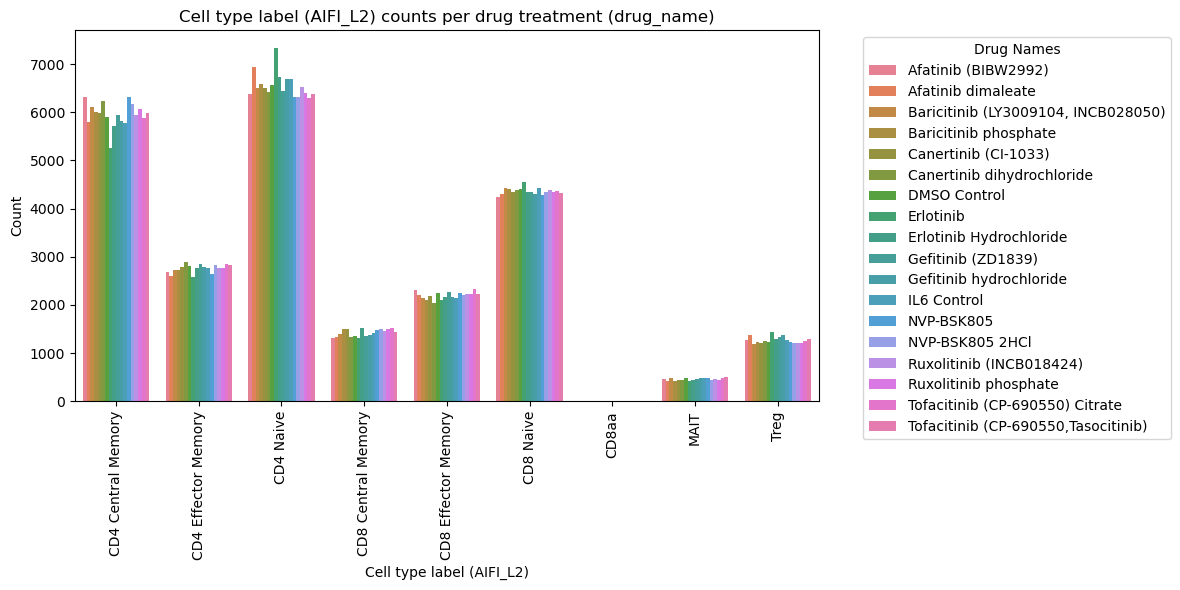

In [30]:
# bar plot:
# x-axis is cell type labels AIFI_L2
# y-axis is count
# hue, what we're grouping by, is drug_name

plt.figure(figsize = (12, 6))
sns.barplot(data = count_df, x = "AIFI_L2", y = "count", hue = "drug_name")
plt.xticks(rotation = 90)
plt.title("Cell type label (AIFI_L2) counts per drug treatment (drug_name)")
plt.xlabel("Cell type label (AIFI_L2)")
plt.ylabel("Count")

plt.legend(title="Drug Names", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**The cell type CD8aa is significantly underrepresented, as well as MAIT. This was seen above when the total counts of CD8aa was 25 and MAIT was 8262 (compared to the most annotations CD4 Naive with 118,058).**

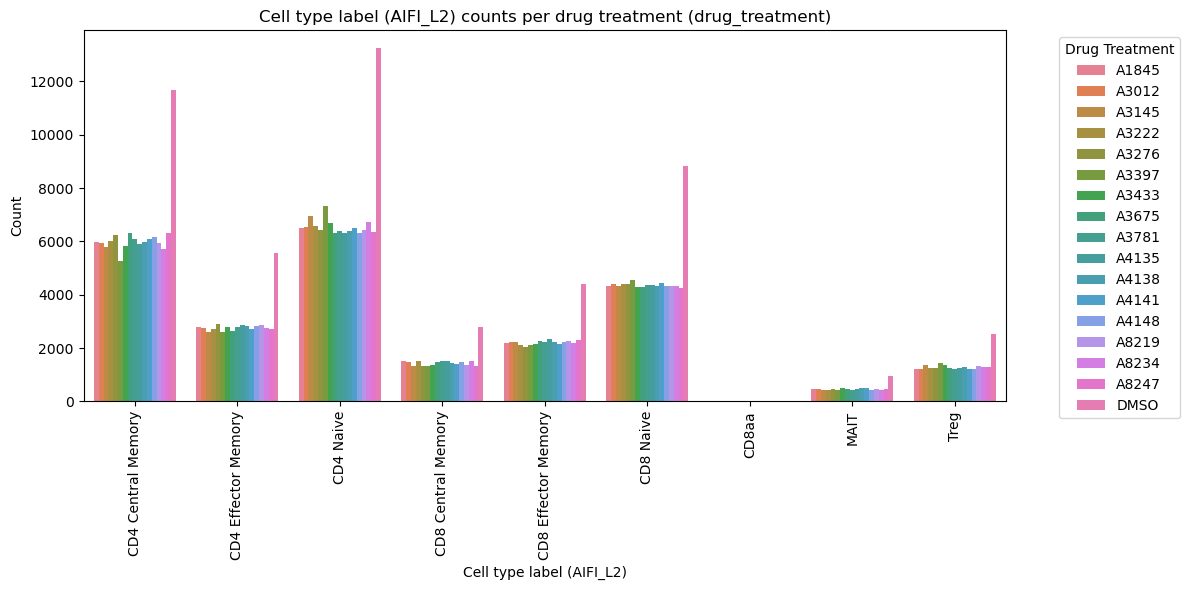

In [31]:
# bar plot:
# x-axis is cell type labels AIFI_L2
# y-axis is count
# hue, what we're grouping by, is drug_treatment

plt.figure(figsize = (12, 6))
sns.barplot(data = count_df2, x = "AIFI_L2", y = "count", hue = "drug_treatment")
plt.xticks(rotation = 90)
plt.title("Cell type label (AIFI_L2) counts per drug treatment (drug_treatment)")
plt.xlabel("Cell type label (AIFI_L2)")
plt.ylabel("Count")

plt.legend(title="Drug Treatment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**It seems like the cell label "CD8aa" is underrepresented as well as MAIT. This shows the same trend as with the drug_name plot.**

## Heatmap to see if any cell labels are underrepresented:

In [33]:
# heatmap: requires a matrix.

# convert dataframe to a matrix:
# "index" will be the rows of the heatmap (the 18 drug treatments (drug_names))
# "columns" will be the columns (the cell labels (AIFI_L2))
# "values" will determine the color intensity (count)
    # aggfunc: apply sum() function to aggregate the "values" (count) by
count_name_matrix = count_df.pivot_table(
    index = "drug_name",
    columns = "AIFI_L2",
    values = "count",
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

count_name_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),6312,2695,6370,1324,2311,4247,2,469,1270
Afatinib dimaleate,5793,2596,6949,1337,2216,4312,1,426,1370
"Baricitinib (LY3009104, INCB028050)",6107,2727,6510,1405,2140,4429,1,484,1197
Baricitinib phosphate,6005,2732,6583,1508,2105,4406,1,425,1235
Canertinib (CI-1033),5994,2785,6512,1502,2192,4344,0,450,1221


In [36]:
# converting the data frame to a matrix for NORMALIZED counts
count_name_norm_matrix = count_df.pivot_table(
    index = "drug_name",
    columns = "AIFI_L2",
    values = "normalized_count",
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

count_name_norm_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),1.000000,0.932203,0.868439,0.869337,0.987607,0.934228,0.153846,0.934263,0.886253
Afatinib dimaleate,0.917776,0.897959,0.947376,0.877873,0.947009,0.948526,0.076923,0.848606,0.956036
"Baricitinib (LY3009104, INCB028050)",0.967522,0.943272,0.887526,0.922521,0.914530,0.974263,0.076923,0.964143,0.835311
Baricitinib phosphate,0.951362,0.945002,0.897478,0.990151,0.899573,0.969204,0.076923,0.846614,0.861828
Canertinib (CI-1033),0.949620,0.963334,0.887798,0.986211,0.936752,0.955565,0.000000,0.896414,0.852059


In [37]:
# converting the data frame to a matrix for RESCALED, NORMALIZED counts
count_name_norm_matrix = count_df.pivot_table(
    index = "drug_name",
    columns = "AIFI_L2",
    values = "normalized_count",
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

count_name_norm_matrix.head()

count_name_rescale_norm_matrix = count_df.pivot_table(
    index = "drug_name",
    columns = "AIFI_L2",
    values = "rescaled_count",
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

count_name_rescale_norm_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),1.000000,0.346667,0.064922,0.061321,0.903333,0.000000,0.083333,0.597561,0.309322
Afatinib dimaleate,0.502874,0.016667,0.625969,0.122642,0.586667,0.217391,0.000000,0.073171,0.733051
"Baricitinib (LY3009104, INCB028050)",0.803640,0.453333,0.200581,0.443396,0.333333,0.608696,0.000000,0.780488,0.000000
Baricitinib phosphate,0.705939,0.470000,0.271318,0.929245,0.216667,0.531773,0.000000,0.060976,0.161017
Canertinib (CI-1033),0.695402,0.646667,0.202519,0.900943,0.506667,0.324415,0.000000,0.365854,0.101695


In [39]:
count_treatment_matrix = count_df2.pivot_table(
    index = "drug_treatment",
    columns = "AIFI_L2",
    values = "count",
    aggfunc = "sum",
    fill_value = 0,
    # get rid of update warning
    observed = False
)

count_treatment_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_treatment,,,,,,,,,
A1845,5994,2785,6512,1502,2192,4344,0,450,1221
A3012,5941,2767,6535,1463,2223,4386,3,463,1219
A3145,5793,2596,6949,1337,2216,4312,1,426,1370
A3222,6005,2732,6583,1508,2105,4406,1,425,1235
A3276,6237,2891,6424,1333,2040,4384,0,448,1243


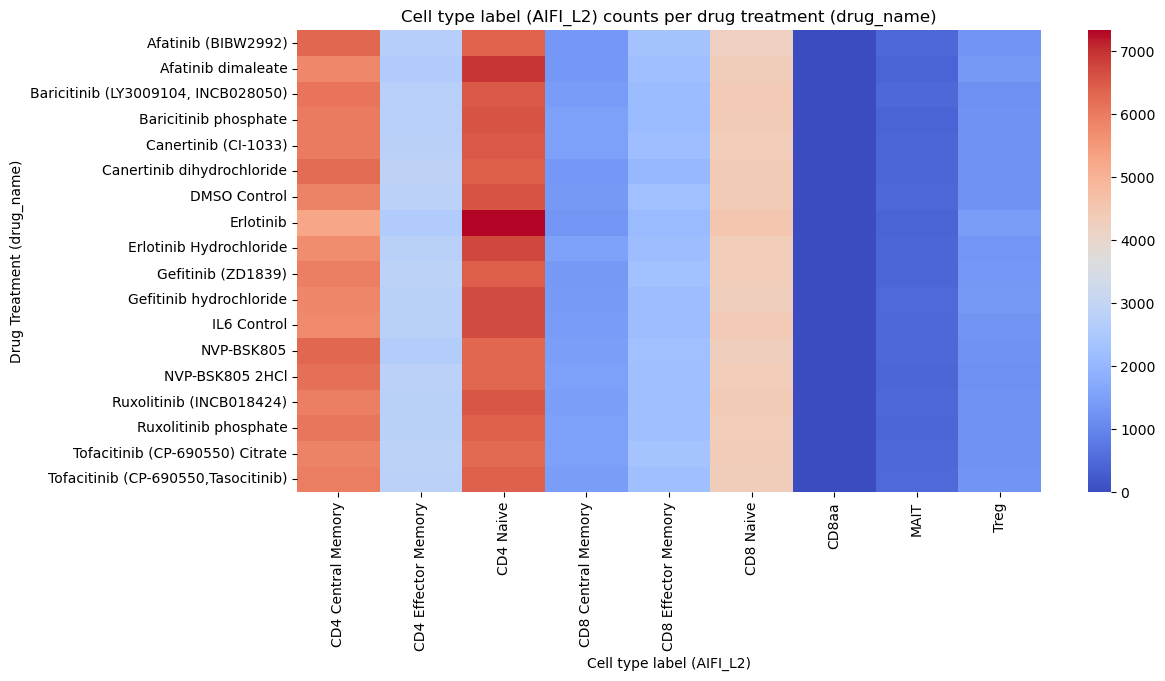

In [42]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label (AIFI_L2) counts per drug treatment (drug_name)")
plt.xlabel("Cell type label (AIFI_L2)")
plt.ylabel("Drug Treatment (drug_name)")
plt.show()

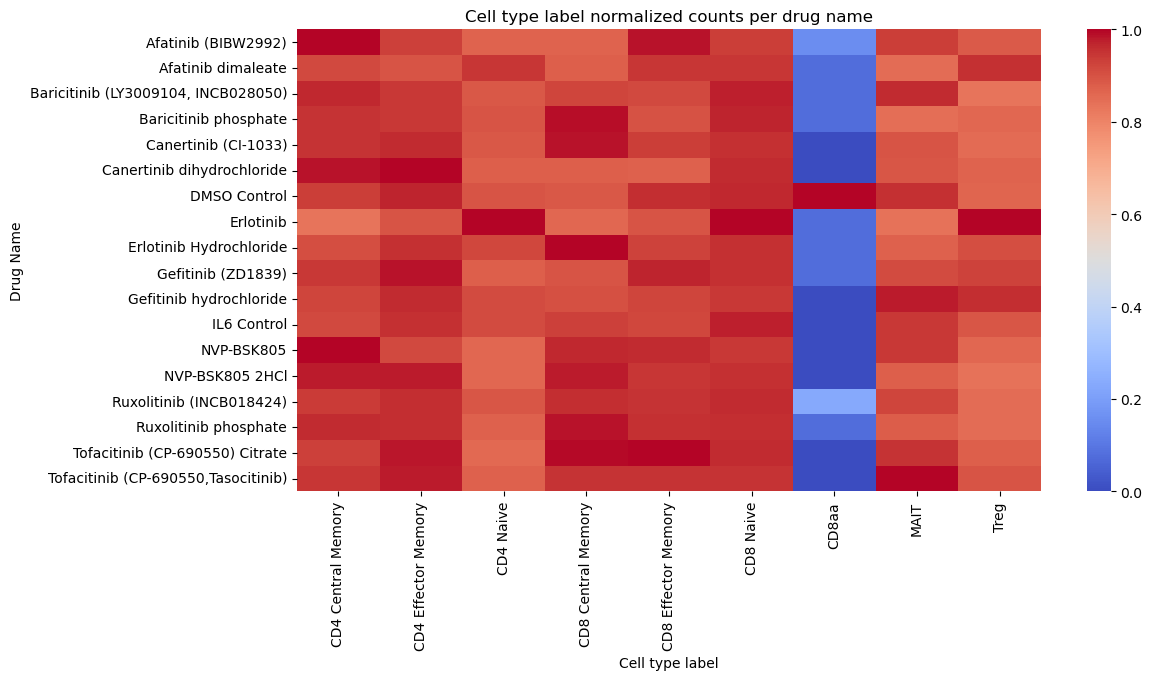

In [43]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_norm_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label normalized counts per drug name")
plt.xlabel("Cell type label")
plt.ylabel("Drug Name")
plt.show()

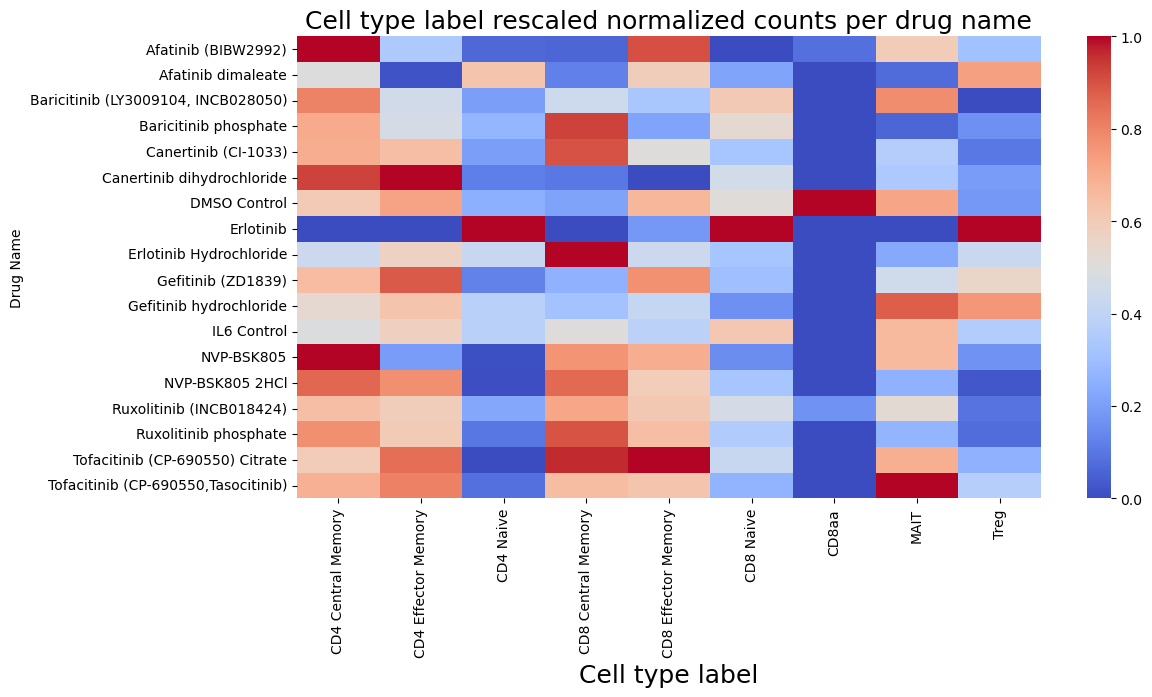

In [44]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_rescale_norm_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label rescaled normalized counts per drug name", fontsize=18)
plt.xlabel("Cell type label", fontsize=18)
plt.ylabel("Drug Name")
plt.show() 

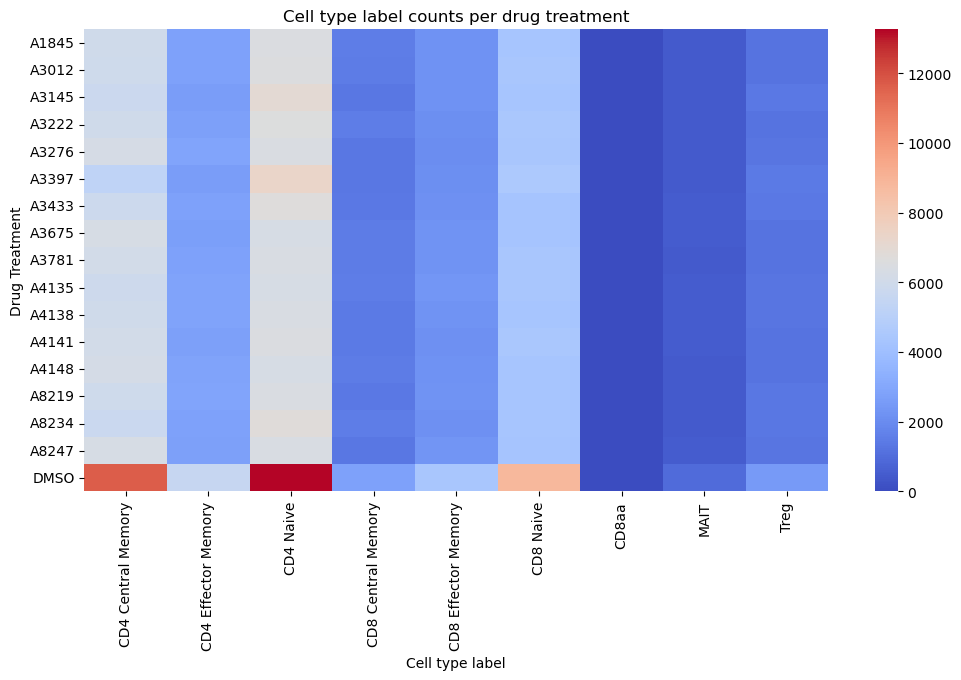

In [45]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_treatment_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label counts per drug treatment")
plt.xlabel("Cell type label")
plt.ylabel("Drug Treatment")
plt.show()

**Again, it seems like the cell labels CD8aa, MAIT, and possibly Treg and CD8 Central Memory are underpresented-- similar to the bar plots.**

# Scanpy Preprocessing, Dimensionality Reduction & Clustering

## Normalization

We fixed some things here by normalizing and log-transforming the data **before** getting highly variable genes (got rid of the scaling and it fixed the errors). (NOTE: HVG is for dimensionality reduction analyses, not DEG and downstream stuff).

In [46]:
#rescaling each cell to a specific library size
sc.pp.normalize_total(adata, target_sum = 1e4)
#applying a log-transform to the data
sc.pp.log1p(adata)

#sc.pp.scale(adata)
#this was causing issues, the sc.pp.highly_variable_genes runs on normalized, log-transformed, unscaled data.

The 3 steps above (normalization, log-transformation, and centering) ensures that all of the genes are on a similar scale. Having all the genes on a similar scale prevents any highly expressed genes from affecting or skewing downstream analyses. 

## Feature Selection

`pp.highly_variable_genes` annotates highly variable genes.

In [61]:
# manually chose the top 500 genes!
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="sample") 

# if following Scanpy tutorial's ad.concat(adata_list, label="sample") --> batch_key can be "sample", like in the Scanpy tutorial
# if using sc.concat(adata_list) --> batch_key should be "drug_name"

In [62]:
#checking to see how many highly variable genes were selected by us; just to verify that 500 genes were actually selected.
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

Number of highly variable genes: 410


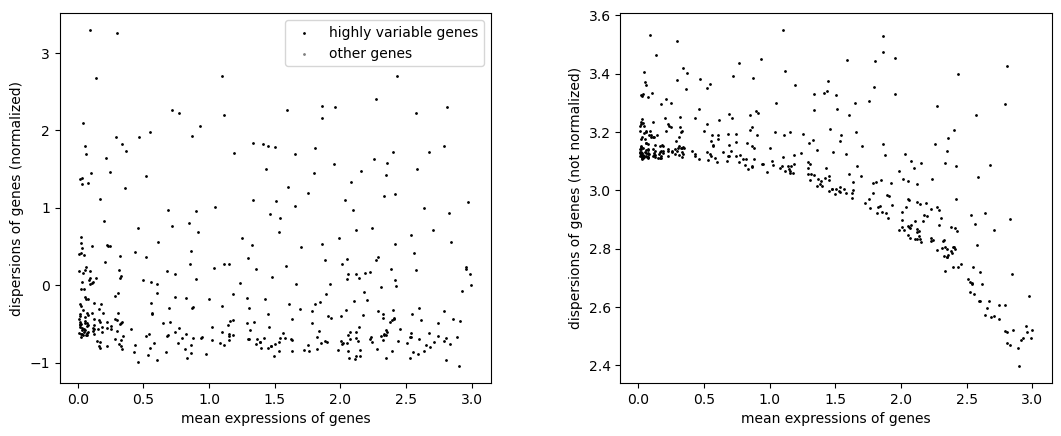

In [64]:
# plotting the (specified) top 500 highly variable genes
sc.pl.highly_variable_genes(adata)

### Selecting top x amount of genes based on several parameters to get the highly variable genes

In [65]:
# trying to get highly variable genes by using parameters
sc.pp.highly_variable_genes(adata, min_mean=0.0125, min_disp=0.1, batch_key="sample")

In [66]:
# checking to see how many highly variable genes were selected 
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

Number of highly variable genes: 135


**It looks like with these parameters (minimum mean and mean dispersion), there are a good amount of highly variable genes! (400)**

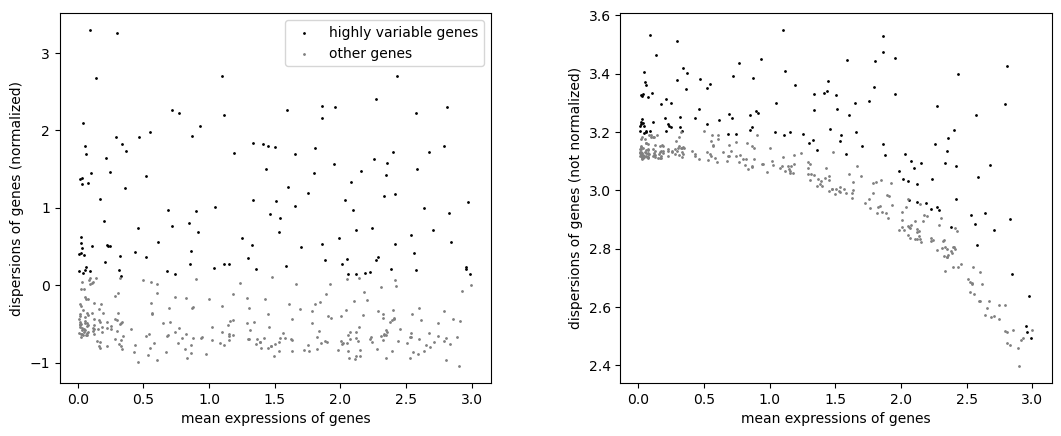

In [67]:
# plotting the top 410 highly variable genes
sc.pl.highly_variable_genes(adata)

In [68]:
#keeping only the highly variable genes
adata = adata[:, adata.var.highly_variable].copy()

In [69]:
adata

AnnData object with n_obs × n_vars = 450000 × 135
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'

**Verified that it kept only 410 genes (out of 1,916 genes) but there are still 450,000 obersvations.**

**There are still 25,000 cells per sample and 18 samples =  450,000 observations**

In [71]:
# scaling the data to use for dimensionality reduction
sc.pp.scale(adata, max_value=10)

## Dimensionality Reduction: PCA, UMAPs

In [72]:
# Reduce the dimensionality of the data by running principal component analysis (PCA)
sc.tl.pca(adata)

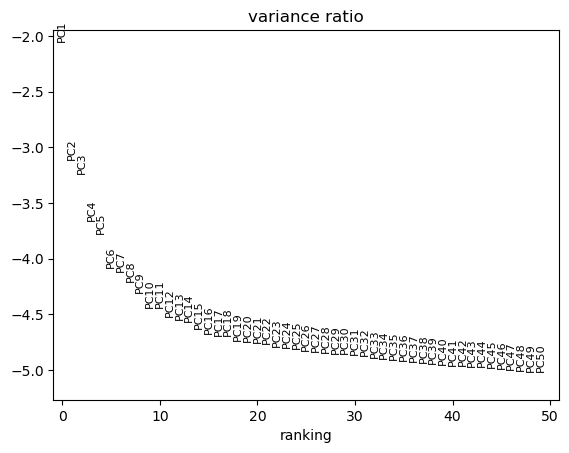

In [74]:
# Plotting the PCA variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

From Scanpy tutorial: "You can also plot the principal components to see if there are any potentially undesired features (e.g. batch, QC metrics) driving signifigant variation in this dataset."

**Note: `sample` is the same as `drug_name`.**

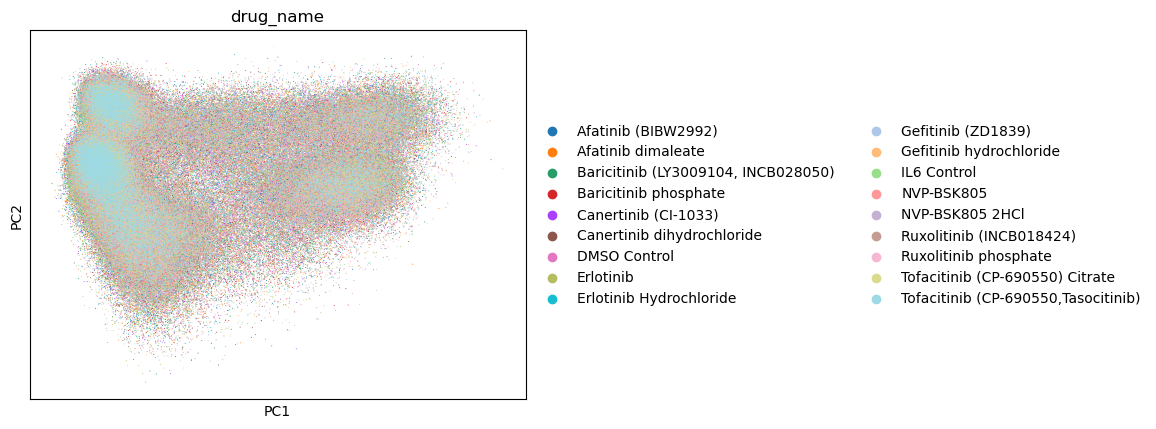

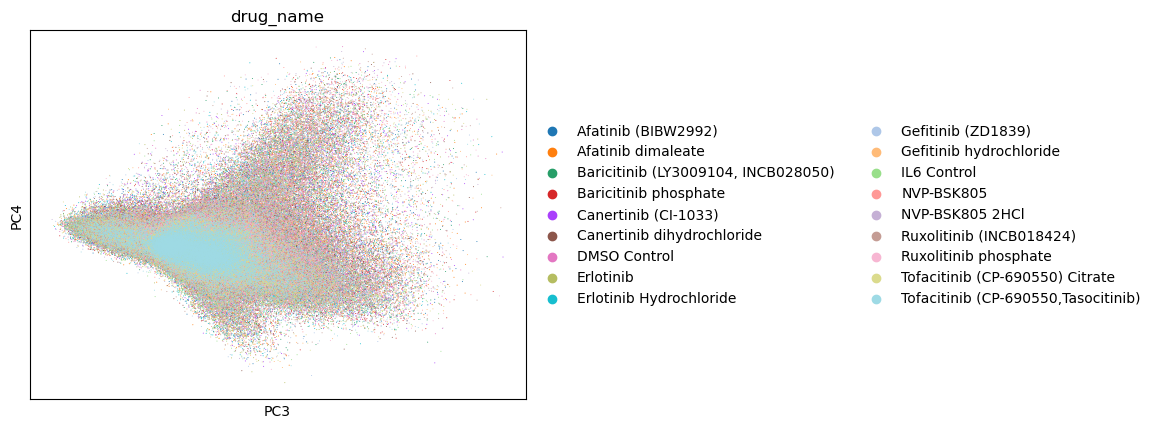

In [79]:
# Create PCA plots of PCA 1 and 2, and PCA 2 and 3, based on drug_name
sc.pl.pca(
    adata,
    color = ["drug_name"],
    dimensions=[(0, 1)],
    ncols=2,
    size=2
)

sc.pl.pca(
    adata,
    color = ["drug_name"],
    dimensions=[(2, 3)],
    ncols=2,
    size=2
)

**There are not many clear clusters. There are too many drug names. Let's look at the cell type.**

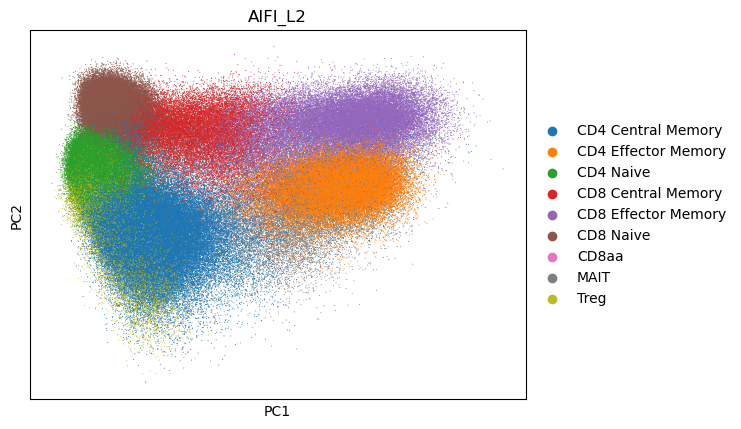

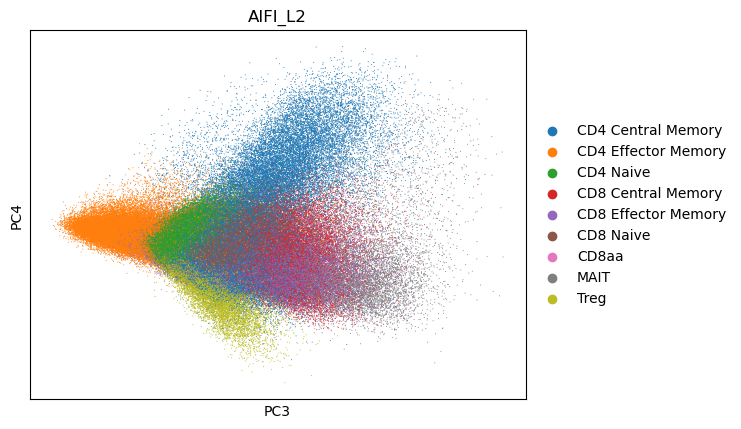

In [81]:
sc.pl.pca(
    adata,
    color = ["AIFI_L2"],
    dimensions=[(0, 1)],
    ncols=2,
    size=2
)

sc.pl.pca(
    adata,
    color = ["AIFI_L2"],
    dimensions=[(2, 3)],
    ncols=2,
    size=2
)

**There are clear clusters from the cell types!**

### Nearest neighbor graph construction and visualization: UMAP!

In [84]:
# Calculate a neighborhood graph of observations based on similarity
sc.pp.neighbors(adata) # n_neighbors = 15, n_pcs = 30

In [85]:
# Reducing the dimensionality of the data to plot with UMAP
sc.tl.umap(adata)

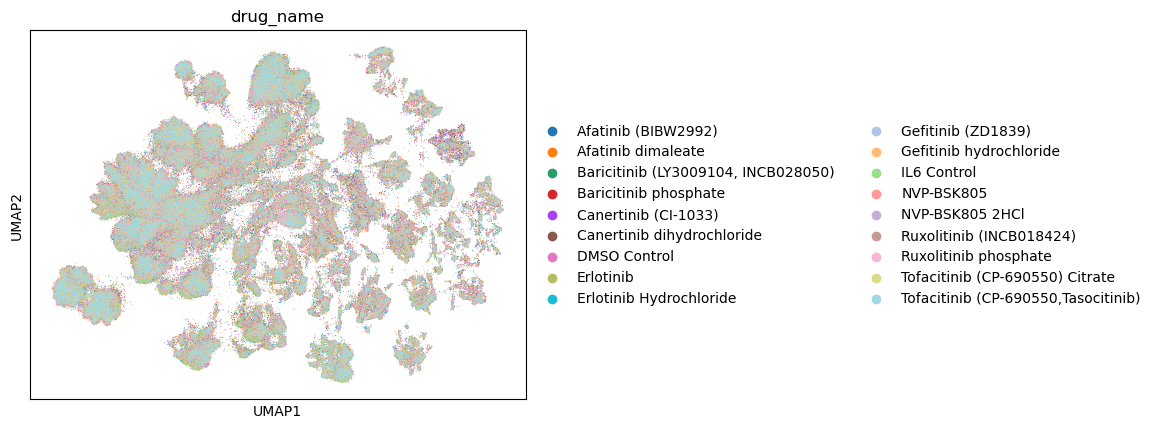

In [86]:
# Plot a UMAP using drug_name
sc.pl.umap(
    adata,
    color="drug_name",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

**Similar to PCA plots, too many drug names to see clear colored-clusters. However, there are some physically apparent clusters.** 

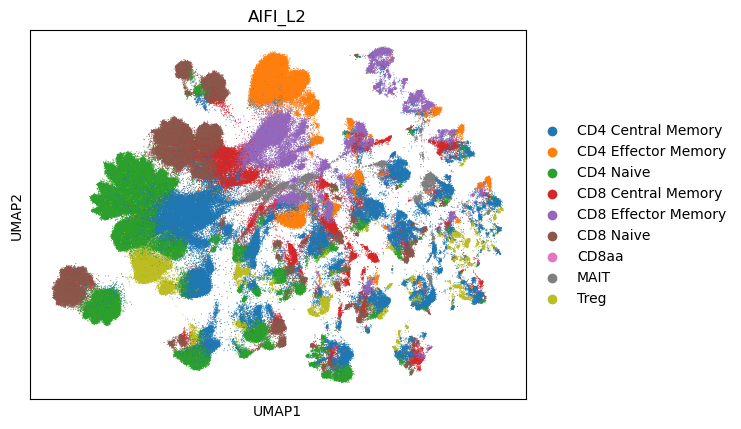

In [87]:
# Plot a UMAP using AIFI_L2 (cell type)
sc.pl.umap(
    adata,
    color="AIFI_L2",
    size=2,
)

## Clustering

In [88]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

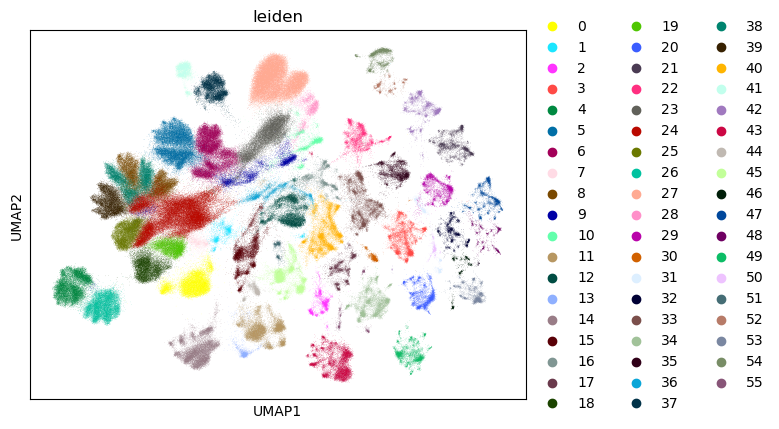

In [89]:
sc.pl.umap(adata, color=["leiden"])